In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/ashu9990/excel-dataset/Dataset for Data Analytics.xlsx


# **UPLOADING DATASET**
* **E-commerce-orders-and-customer-analytics-dataset/ecommerce_orders_dataset**

In [2]:
import pandas as pd

file_path = "/kaggle/input/datasets/ashu9990/excel-dataset/Dataset for Data Analytics.xlsx"
df = pd.read_excel(file_path)
print("Original Shape:", df.shape)
df

Original Shape: (1200, 14)


,OrderID,Date,CustomerID,Product,Quantity,UnitPrice,ShippingAddress,PaymentMethod,OrderStatus,TrackingNumber,ItemsInCart,CouponCode,ReferralSource,TotalPrice
0,ORD200000,2023-01-04,C72649,Monitor,5,570.62,928 Main St,Debit Card,Shipped,TRK37947903,7,SAVE10,Instagram,2853.10
1,ORD200001,2024-08-23,C75739,Phone,2,151.35,823 Main St,Online,Shipped,TRK91186779,3,SAVE10,Referral,302.70
2,ORD200002,2024-02-27,C81728,Tablet,5,550.68,512 Main St,Credit Card,Cancelled,TRK42903982,8,FREESHIP,Email,2753.40
3,ORD200003,2023-10-15,C33540,Chair,1,273.19,275 Main St,Debit Card,Returned,TRK62788070,5,SAVE10,Facebook,273.19
4,ORD200004,2025-05-08,C81840,Printer,4,626.01,668 Main St,Online,Delivered,TRK29241424,8,SAVE10,Email,2504.04
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1195,ORD201195,2024-06-20,C21126,Desk,1,107.04,392 Main St,Credit Card,Cancelled,TRK38009181,6,FREESHIP,Google,107.04
1196,ORD201196,2024-03-04,C20095,Monitor,2,662.53,778 Main St,Online,Cancelled,TRK69207593,5,NaN,Facebook,1325.06
1197,ORD201197,2023-07-13,C79674,Tablet,2,436.84,275 Main St,Online,Delivered,TRK88039356,2,FREESHIP,Instagram,873.68
1198,ORD201198,2024-08-22,C64753,Chair,4,262.52,509 Main St,Debit Card,Cancelled,TRK71683331,4,WINTER15,Instagram,1050.08



# **DATA**




In [3]:
print(df.shape) 

print(df.columns.tolist()) 

(1200, 14)
['OrderID', 'Date', 'CustomerID', 'Product', 'Quantity', 'UnitPrice', 'ShippingAddress', 'PaymentMethod', 'OrderStatus', 'TrackingNumber', 'ItemsInCart', 'CouponCode', 'ReferralSource', 'TotalPrice']


#  **Missing Values**

In [4]:
print(df.isnull().sum()) 

for col in df.columns: 
 if df[col].dtype == "object": 
   df[col].fillna(df[col].mode()[0], inplace=True) 

else: 
 df[col].fillna(df[col].median(), inplace=True) 


OrderID              0
Date                 0
CustomerID           0
Product              0
Quantity             0
UnitPrice            0
ShippingAddress      0
PaymentMethod        0
OrderStatus          0
TrackingNumber       0
ItemsInCart          0
CouponCode         309
ReferralSource       0
TotalPrice           0
dtype: int64


/tmp/ipykernel_58/2806877764.py:9: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].mode()[0], inplace=True)
/tmp/ipykernel_58/2806877764.py:12: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try usin

# **Duplicates**

In [5]:
print("Number of duplicate rows in dataset :", df.duplicated().sum()) 
df = df.drop_duplicates() 


Number of duplicate rows in dataset : 0


# **Clean Text Columns**

In [6]:
object_cols = df.select_dtypes(include="object").columns 

for col in object_cols: 
 df[col] = df[col].astype(str).str.strip().str.title() 


# **Correct Date Columns Format**

In [7]:
for col in df.columns:        
    if "date" in col.lower(): 
        df[col] = pd.to_datetime(df[col], errors="coerce")

# **Final thing**

In [8]:
print(df.isnull().sum()) 

print(df.shape) 

df.to_excel("Cleaned_ Dataset.xlsx", index=False) 

print("Data Cleaning Process completed Successfully :)") 

OrderID            0
Date               0
CustomerID         0
Product            0
Quantity           0
UnitPrice          0
ShippingAddress    0
PaymentMethod      0
OrderStatus        0
TrackingNumber     0
ItemsInCart        0
CouponCode         0
ReferralSource     0
TotalPrice         0
dtype: int64
(1200, 14)
Data Cleaning Process completed Successfully :)


# ***ploting***
* line pilot of PaymentMethod
* kde pilot of top 10 sell product
* bar pilot of distribution of  order status
* pie chat of refrence social media app
* pie chart of Mostly Use Couponcode

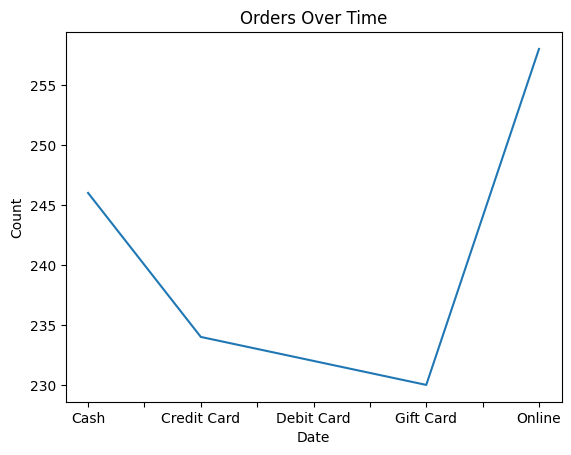

In [9]:
import matplotlib.pyplot as plt

df.groupby('PaymentMethod').size().plot(kind='line')
plt.title('Orders Over Time')
plt.xlabel('Date')
plt.ylabel('Count')
plt.show()

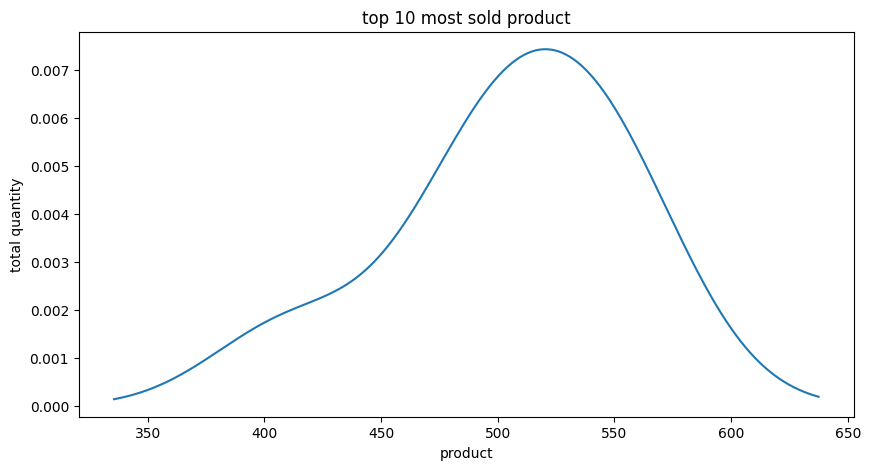

In [21]:
import matplotlib.pyplot as plt
top_products = df.groupby('Product')['Quantity'].sum()

plt.figure(figsize=(10,5))
top_products.plot(kind='kde')

plt.title('top 10 most sold product')
plt.xlabel('product')
plt.ylabel('total quantity')

plt.show()

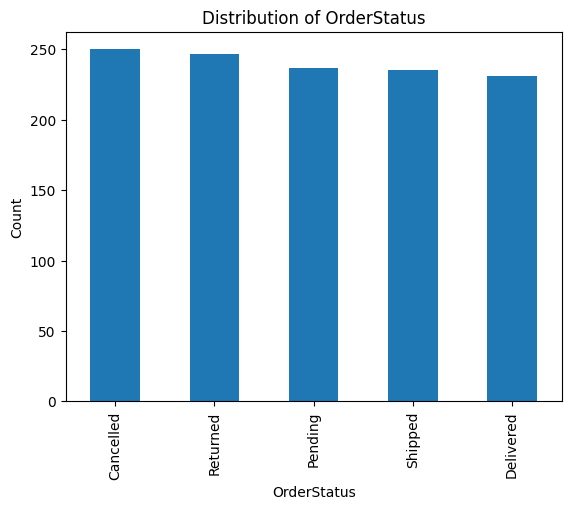

In [27]:
df['OrderStatus'].value_counts().plot(kind='bar')

plt.title('Distribution of OrderStatus')
plt.xlabel('OrderStatus')
plt.ylabel('Count')
plt.show()

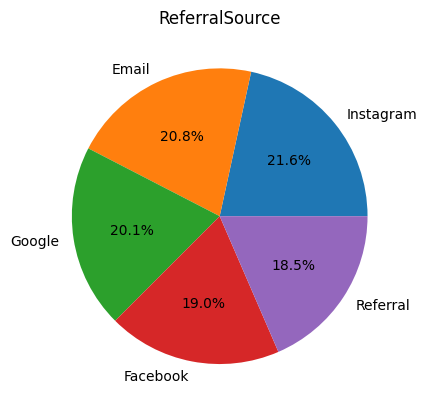

In [34]:
df['ReferralSource'].value_counts().plot(kind='pie', autopct='%1.1f%%')

plt.title("ReferralSource")
plt.ylabel('')
plt.show()

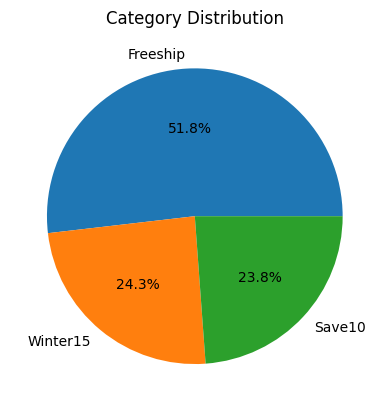

In [29]:
df['CouponCode'].value_counts().plot(kind='pie', autopct='%1.1f%%')

plt.title("Mostly Use Couponcode")
plt.ylabel('')
plt.show()